# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Malfino Muhammad Willianz | 5054251028 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('data.csv')

print('Shape:', df.shape)
df.info()

Shape: (569, 33)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se        

Dataset terdiri dari 569 baris dan 33 kolom: `id`, target `diagnosis` (B = Benign/jinak, M = Malignant/ganas), 30 fitur numerik, serta kolom `Unnamed: 32` yang merupakan artefak dari trailing comma pada file CSV. Ke-30 fitur merupakan 10 karakteristik inti sel (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) yang masing-masing dihitung dalam 3 bentuk: `_mean` (rata-rata), `_se` (standard error), dan `_worst` (rata-rata 3 nilai terbesar).

## Stats

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


Rentang nilai antar fitur sangat berbeda jauh. `area_mean` memiliki mean ≈ 654,9 dan std ≈ 351,9, sedangkan `fractal_dimension_mean` hanya memiliki mean ≈ 0,063 dan std ≈ 0,007. Kolom `id` hanya identitas pasien sehingga tidak relevan sebagai fitur, dan kolom `Unnamed: 32` memiliki `count` = 0 (seluruhnya kosong).

## Missing Value dan Duplikat

In [4]:
print('Jumlah missing value per kolom (yang > 0):')
print(df.isna().sum()[df.isna().sum() > 0])
print()
print('Jumlah baris duplikat:', df.duplicated().sum())
print('Jumlah id duplikat   :', df['id'].duplicated().sum())

Jumlah missing value per kolom (yang > 0):
Unnamed: 32    569
dtype: int64

Jumlah baris duplikat: 0
Jumlah id duplikat   : 0


Satu-satunya kolom yang mengandung missing value adalah `Unnamed: 32`, yang seluruh 569 barisnya kosong, sehingga kolom ini cukup dibuang (bukan diimputasi). Tidak ada baris maupun `id` yang duplikat, artinya setiap baris mewakili satu pasien yang berbeda.

## Target

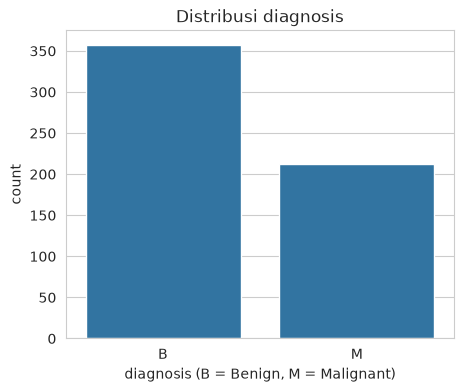

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', data=df, order=['B', 'M'])
plt.title('Distribusi diagnosis')
plt.xlabel('diagnosis (B = Benign, M = Malignant)')
plt.show()

print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True) * 100)

Distribusi target **cukup imbalanced namun tidak ekstrem**: 357 sampel benign (62,74%) dan 212 sampel malignant (37,26%), dengan rasio sekitar 1,7:1. Model "bodoh" yang selalu memprediksi benign sudah mencapai akurasi ±62,7%, sehingga angka ini menjadi baseline minimum. Selain accuracy, recall kelas malignant juga penting dipantau karena pada kasus kanker, *false negative* (tumor ganas diprediksi jinak) jauh lebih berbahaya dibanding *false positive*.

## Distribusi Fitur per Kelas

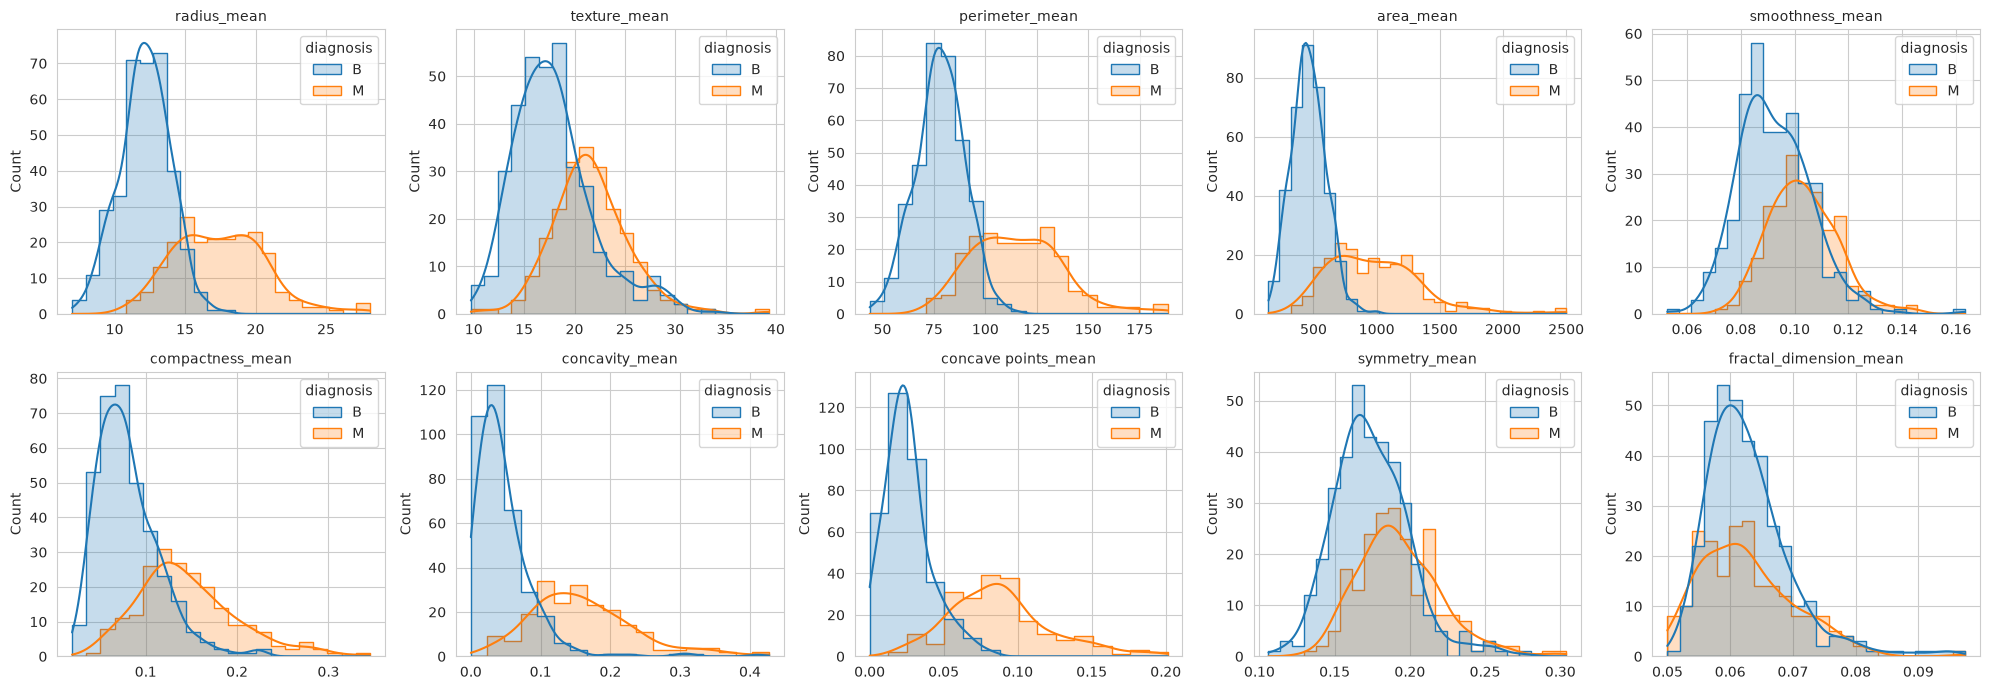

In [6]:
mean_cols = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flatten(), mean_cols):
    sns.histplot(data=df, x=col, hue='diagnosis', hue_order=['B', 'M'], kde=True, ax=ax, element='step')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Histogram fitur `_mean` menunjukkan bahwa fitur yang berkaitan dengan **ukuran** (`radius_mean`, `perimeter_mean`, `area_mean`) dan **bentuk** (`concavity_mean`, `concave points_mean`, `compactness_mean`) memiliki distribusi yang cukup terpisah antar kelas: tumor ganas cenderung lebih besar dan lebih cekung (median `radius_mean` 17,3 vs 12,2). Sebaliknya, `fractal_dimension_mean`, `symmetry_mean`, dan `smoothness_mean` sangat tumpang tindih antar kelas, sehingga kurang informatif jika berdiri sendiri. Beberapa fitur (misalnya `area_mean` dan `concavity_mean`) juga memiliki distribusi yang condong ke kanan (right-skewed).

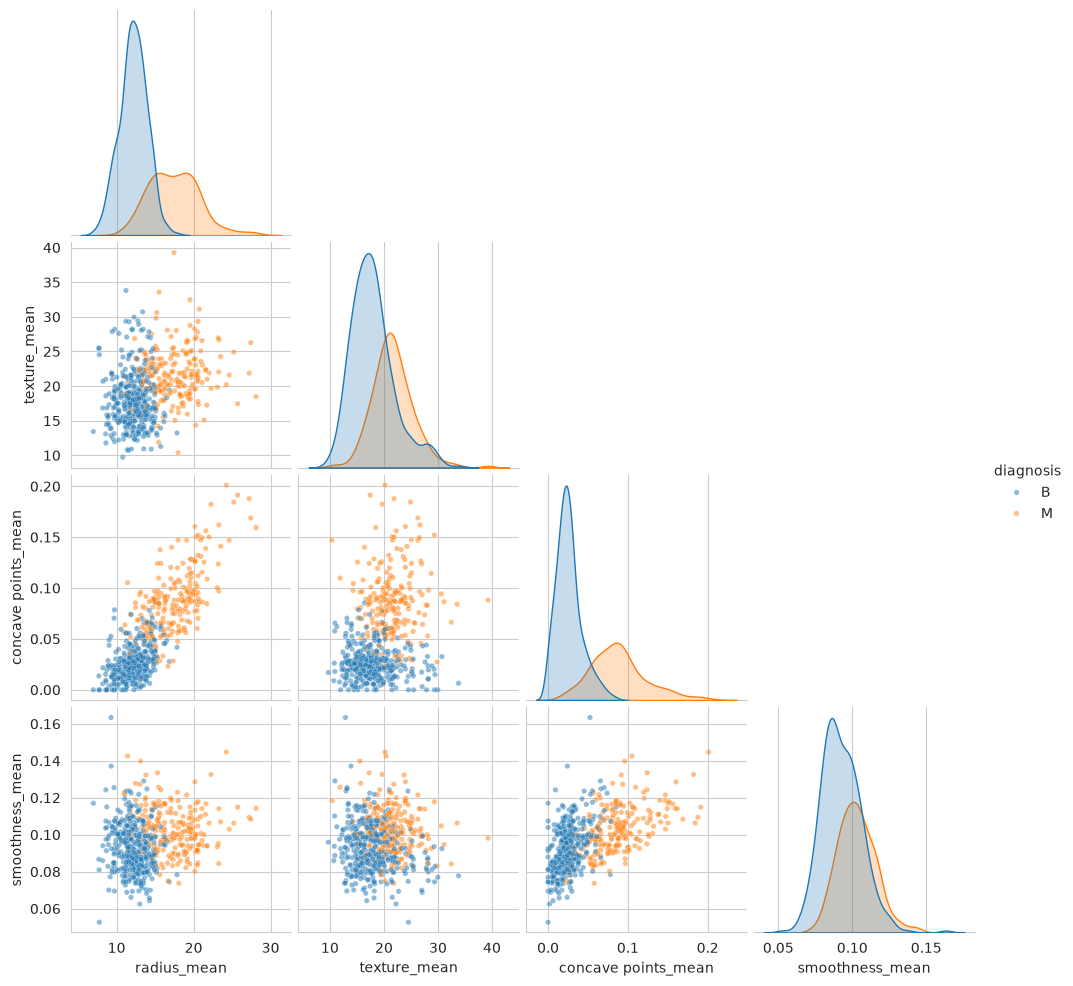

In [7]:
pair_cols = ['radius_mean', 'texture_mean', 'concave points_mean', 'smoothness_mean']
sns.pairplot(df[pair_cols + ['diagnosis']], hue='diagnosis', hue_order=['B', 'M'],
             plot_kws={'alpha': 0.5, 's': 15}, corner=True)
plt.show()

Pairplot memperlihatkan bahwa kombinasi `radius_mean` dan `concave points_mean` sudah memisahkan kedua kelas dengan cukup jelas, dan batas pemisahnya terlihat **hampir berupa garis lurus** (diagonal), dengan hanya sedikit titik yang tumpang tindih di area perbatasan. Hal ini menjadi indikasi awal bahwa data cukup *linearly separable*, sehingga kernel Linear kemungkinan sudah bekerja dengan baik. Pasangan yang melibatkan `smoothness_mean` dan `texture_mean` lebih tumpang tindih.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

### Korelasi Antar Fitur

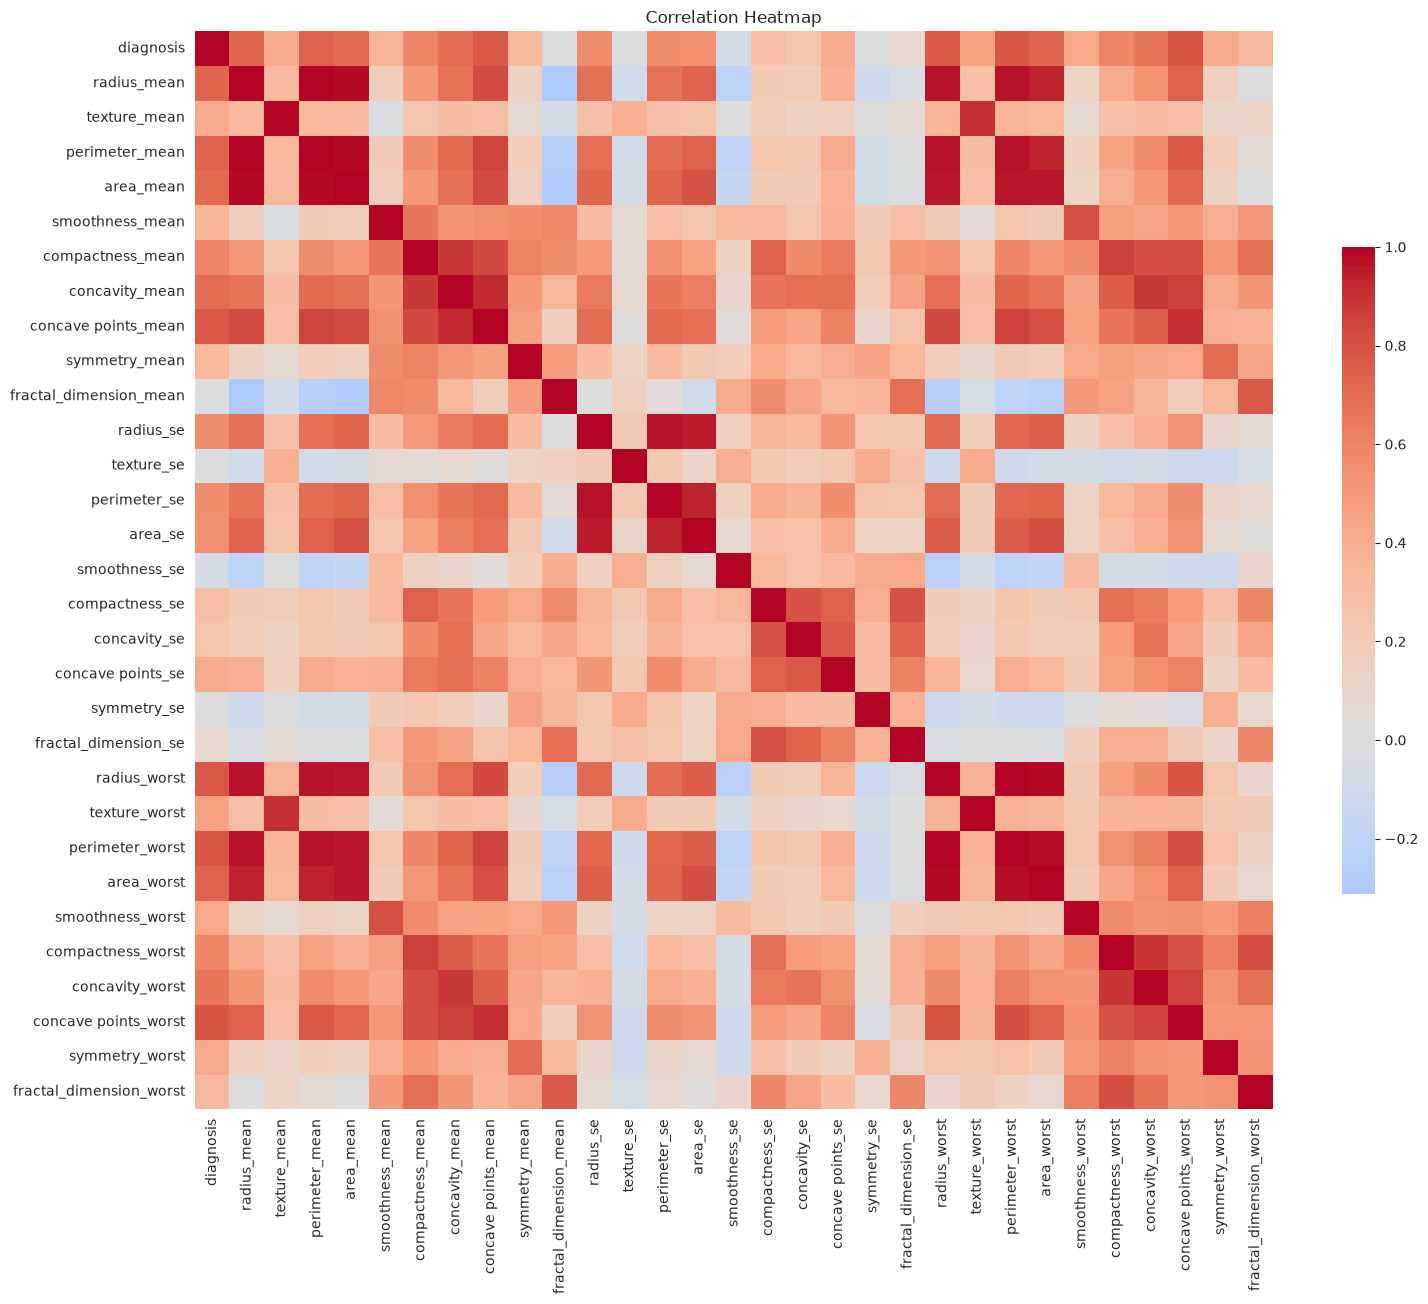

In [8]:
df_corr = df.drop(columns=['id', 'Unnamed: 32']).assign(diagnosis=lambda d: (d['diagnosis'] == 'M').astype(int))
corr_matrix = df_corr.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.6})
plt.title('Correlation Heatmap')
plt.show()

Heatmap korelasi menunjukkan banyak fitur yang sangat redundan, terutama kelompok ukuran (`radius`, `perimeter`, `area`) yang saling berkorelasi hampir sempurna (r ≈ 0,99), karena secara geometris perimeter dan area diturunkan dari radius. Hal yang sama terjadi antara versi `_mean` dan `_worst` dari fitur yang sama. Secara total terdapat 21 pasangan fitur dengan |r| > 0,9. Untuk SVM, multikolinearitas ini tidak terlalu bermasalah karena regularisasi `C` mencegah bobot menjadi tidak stabil, sehingga seluruh fitur tetap digunakan.

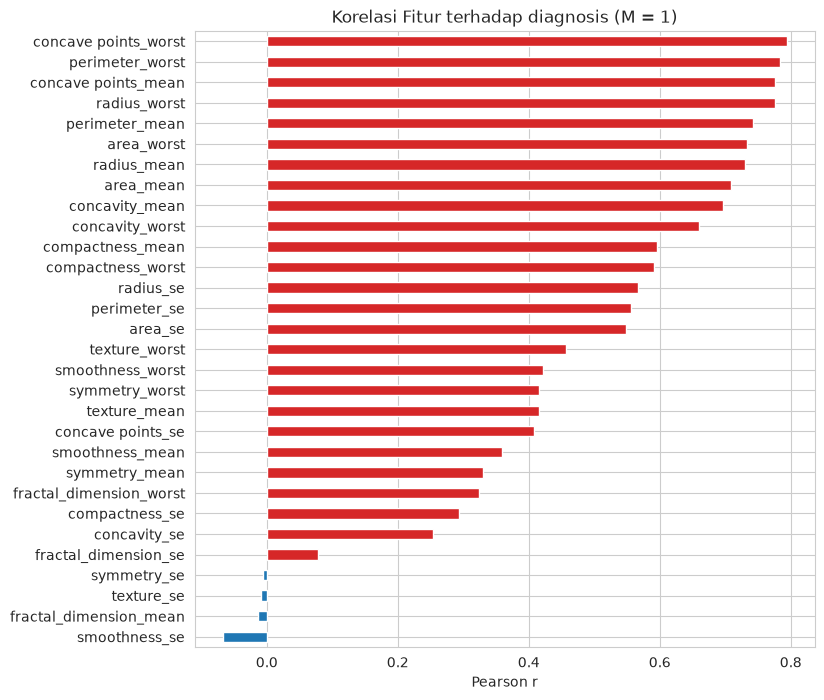

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64

In [9]:
target_corr = corr_matrix['diagnosis'].drop('diagnosis').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 8))
target_corr.sort_values().plot.barh(color=['tab:red' if v > 0 else 'tab:blue' for v in target_corr.sort_values()])
plt.title('Korelasi Fitur terhadap diagnosis (M = 1)')
plt.xlabel('Pearson r')
plt.show()

target_corr.head(10)

Fitur dengan korelasi tertinggi terhadap diagnosis ganas adalah `concave points_worst` (r ≈ 0,79), `perimeter_worst` (r ≈ 0,78), `concave points_mean` (r ≈ 0,78), dan `radius_worst` (r ≈ 0,78). Banyaknya fitur dengan korelasi linear yang kuat (> 0,7) terhadap target juga mendukung dugaan bahwa batas keputusan antar kelas sebagian besar bersifat linear.

### Skala Antar Fitur

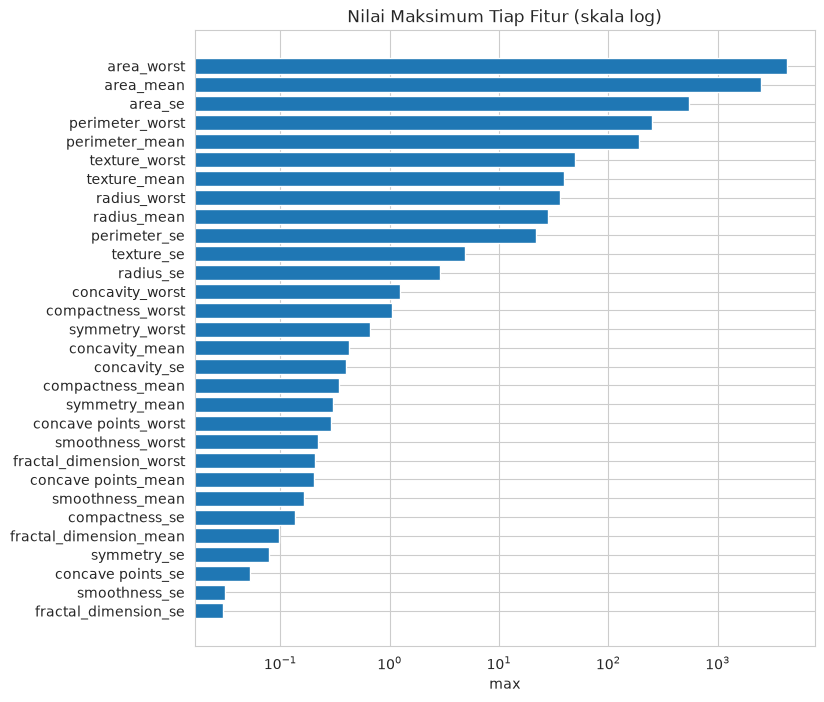

,min,max,std
area_worst,185.200,4254.0,569.356993
area_mean,143.500,2501.0,351.914129
area_se,6.802,542.2,45.491006
perimeter_worst,50.410,251.2,33.602542
perimeter_mean,43.790,188.5,24.298981


In [10]:
feature_cols = df.columns.drop(['id', 'diagnosis', 'Unnamed: 32'])
scale_info = df[feature_cols].agg(['min', 'max', 'std']).T.sort_values('max', ascending=False)

plt.figure(figsize=(8, 8))
plt.barh(scale_info.index[::-1], scale_info['max'][::-1])
plt.xscale('log')
plt.title('Nilai Maksimum Tiap Fitur (skala log)')
plt.xlabel('max')
plt.show()

scale_info.head(5)

Nilai maksimum antar fitur berbeda hingga 5 orde besaran: `area_worst` mencapai 4.254, sedangkan fitur seperti `fractal_dimension_se` maksimumnya < 0,03. Tanpa scaling, perhitungan jarak/dot product pada SVM akan didominasi oleh fitur `area_*` dan `perimeter_*`, sementara fitur bentuk yang sebenarnya informatif (misalnya `concave points`) hampir tidak berkontribusi.

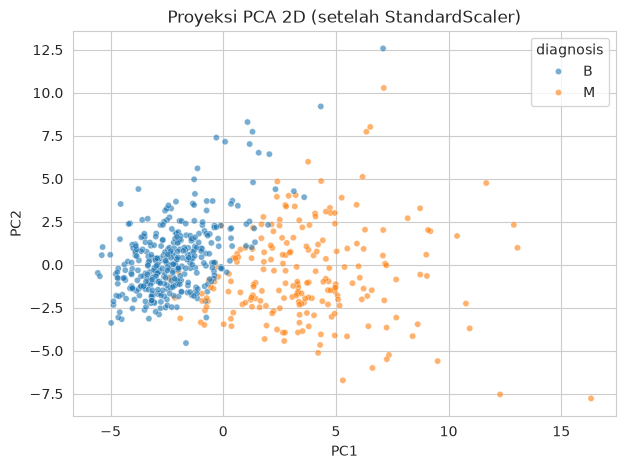

In [11]:
X_pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(df[feature_cols]))

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['diagnosis'], hue_order=['B', 'M'], alpha=0.6, s=20)
plt.title('Proyeksi PCA 2D (setelah StandardScaler)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Setelah distandarisasi dan diproyeksikan ke 2 komponen utama, kedua kelas sudah terlihat cukup terpisah, terutama sepanjang sumbu PC1. Benign membentuk cluster yang padat di sisi kiri, sedangkan malignant lebih menyebar ke kanan. Area tumpang tindih hanya terdapat di sekitar perbatasan kedua cluster. *(Catatan: PCA di sini hanya untuk eksplorasi visual pada seluruh data; pada tahap modelling, scaler dan PCA hanya di-fit pada train set.)*

# 2. Preprocessing

In [12]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df = df.drop(columns=['id', 'Unnamed: 32'])
print('Total missing value:', df.isna().sum().sum())

Total missing value: 0


In [13]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Hanya target yang kategorikal (B/M), sehingga cukup di-encode menjadi 0/1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
print(df.select_dtypes(exclude='number').columns.tolist())
print(df['diagnosis'].value_counts())

[]
diagnosis
0    357
1    212
Name: count, dtype: int64


In [14]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train shape: (455, 30)
Test shape : (114, 30)
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [15]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Mean train (5 fitur pertama):', X_train_scaled.mean(axis=0)[:5].round(3))
print('Std train  (5 fitur pertama):', X_train_scaled.std(axis=0)[:5].round(3))
print('Mean test  (5 fitur pertama):', X_test_scaled.mean(axis=0)[:5].round(3))

Mean train (5 fitur pertama): [-0.  0.  0. -0.  0.]
Std train  (5 fitur pertama): [1. 1. 1. 1. 1.]
Mean test  (5 fitur pertama): [-0.054 -0.149 -0.05  -0.065  0.128]


Preprocessing yang dilakukan:

| Tahap | Keputusan |
|---|---|
| Missing value | Kolom `Unnamed: 32` (100% kosong) dibuang; fitur lain tidak memiliki missing value sehingga tidak perlu imputasi |
| Kolom tidak relevan | `id` dibuang karena hanya identitas pasien |
| Encoding | Hanya target yang kategorikal: `B` → 0, `M` → 1 (kelas positif = ganas) |
| Split | 80:20 dengan `stratify=y` → 455 train, 114 test (proporsi malignant ±37% di keduanya) |
| Scaling | `StandardScaler` di-fit hanya pada `X_train`, lalu di-transform ke train dan test |

Mean dan std pada train set setelah scaling tepat 0 dan 1, sedangkan mean pada test set sedikit bergeser dari 0 (misalnya -0,149 pada `texture_mean`). Hal ini memang seharusnya terjadi karena test set ditransformasi dengan statistik dari train set, yang menunjukkan bahwa tidak ada informasi test set yang bocor ke proses scaling.

## 2.1 Eksperimen: Pengaruh Feature Scaling

In [16]:
scaling_results = []
for kernel in ['linear', 'rbf']:
    for name, (Xtr, Xte) in {'Tanpa scaling': (X_train, X_test),
                             'StandardScaler': (X_train_scaled, X_test_scaled)}.items():
        model = SVC(kernel=kernel, C=1.0, random_state=42).fit(Xtr, y_train)
        scaling_results.append({
            'Kernel': kernel, 'Scaling': name,
            'Train Accuracy': accuracy_score(y_train, model.predict(Xtr)),
            'Test Accuracy': accuracy_score(y_test, model.predict(Xte)),
            'Test F1': f1_score(y_test, model.predict(Xte)),
            'Jumlah SV': model.n_support_.sum(),
        })

pd.DataFrame(scaling_results).set_index(['Kernel', 'Scaling'])

Train Accuracy  Test Accuracy   Test F1  Jumlah SV
Kernel Scaling                                                           
linear Tanpa scaling         0.973626       0.921053  0.886076         45
       StandardScaler        0.989011       0.964912  0.950000         38
rbf    Tanpa scaling         0.918681       0.903509  0.849315        120
       StandardScaler        0.986813       0.973684  0.962963        107

Eksperimen tambahan ini membuktikan pentingnya feature scaling untuk SVM. Dengan hyperparameter yang sama (`C=1`), scaling menaikkan test accuracy kernel Linear dari 92,11% menjadi 96,49%, dan kernel RBF dari 90,35% menjadi 97,37%. Efeknya lebih besar pada RBF, karena kernel RBF menghitung jarak Euclidean secara langsung (`exp(-gamma·||x - x'||²)`), sehingga tanpa scaling jarak hampir sepenuhnya ditentukan oleh `area_worst` dan `area_mean`. Selain itu, jumlah support vector juga berkurang setelah scaling (45 → 38 pada Linear, 120 → 107 pada RBF), menandakan margin yang terbentuk lebih "bersih". Seluruh eksperimen berikutnya menggunakan data yang sudah di-scaling.

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [17]:
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

print('Jumlah support vector per kelas:', svm_linear.n_support_)

Jumlah support vector per kelas: [19 19]


In [18]:
linear_predictions = svm_linear.predict(X_test_scaled)

## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [19]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

print('Jumlah support vector per kelas:', svm_rbf.n_support_)

Jumlah support vector per kelas: [50 57]


In [20]:
rbf_predictions = svm_rbf.predict(X_test_scaled)

Kedua model dilatih dengan `C=1.0` (default) agar perbandingan adil, dan model RBF menggunakan `gamma='scale'` (= 1 / (n_fitur × var(X)) ≈ 0,0333 setelah standardisasi). Model Linear hanya membutuhkan **38 support vector** (19 per kelas), sedangkan model RBF membutuhkan **107 support vector** (50 benign, 57 malignant), hampir 3 kali lipat lebih banyak.

## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [21]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

c_models = {}
for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    c_models[c] = model

In [22]:
results = []
for c, model in c_models.items():
    results.append({
        'C': c,
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'Test Accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        'Jumlah SV': model.n_support_.sum(),
    })

c_results = pd.DataFrame(results).set_index('C')
c_results

,Train Accuracy,Test Accuracy,Jumlah SV
C,,,
0.001,0.626374,0.631579,340
0.010,0.626374,0.631579,341
0.100,0.953846,0.947368,202
1.000,0.986813,0.973684,107
10.000,0.989011,0.973684,82
100.000,1.000000,0.964912,70
1000.000,1.000000,0.964912,70


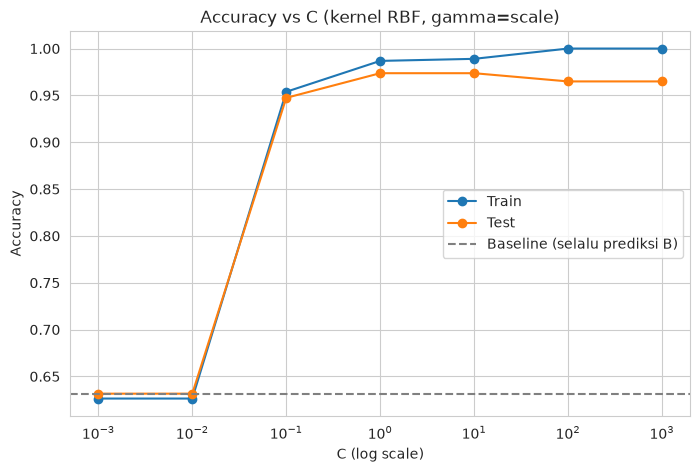

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(c_results.index, c_results['Train Accuracy'], marker='o', label='Train')
plt.plot(c_results.index, c_results['Test Accuracy'], marker='o', label='Test')
plt.axhline(1 - y_test.mean(), linestyle='--', color='gray', label='Baseline (selalu prediksi B)')
plt.xscale('log')
plt.title('Accuracy vs C (kernel RBF, gamma=scale)')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Grafik di atas memperlihatkan ketiga fase regularisasi dengan jelas:

- **Underfitting (C ≤ 0,01):** penalti kesalahan terlalu kecil sehingga margin terlalu lebar dan model memprediksi semua sampel sebagai benign. Akurasi train (62,64%) dan test (63,16%) sama persis dengan baseline, dan hampir seluruh data train (340 dari 455) menjadi support vector.
- **Sweet spot (C = 1 s.d. 10):** test accuracy mencapai puncak 97,37%, dengan gap train-test yang kecil (≈ 1,3–1,5%).
- **Overfitting (C ≥ 100):** train accuracy mencapai 100% (model memisahkan seluruh data train dengan sempurna), sedangkan test accuracy justru turun ke 96,49%. Jumlah support vector juga menurun ke 70, karena margin yang sempit hanya ditentukan oleh sedikit titik di perbatasan.

Gejala overfitting mulai terlihat pada **C = 100**, yaitu ketika train accuracy terus naik sementara test accuracy mulai menurun. Penurunannya tidak drastis (hanya 1 sampel test), karena dengan `gamma='scale'` yang kecil, batas keputusan RBF masih cukup halus meskipun C besar.

### Pengaruh gamma

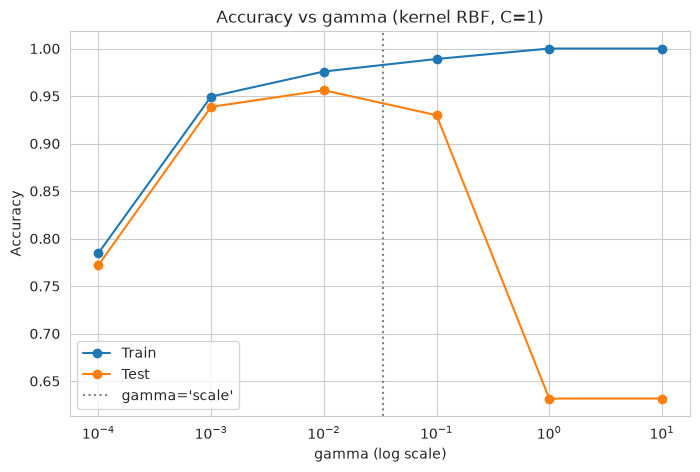

,Train Accuracy,Test Accuracy,Jumlah SV
gamma,,,
0.0001,0.784615,0.771930,328
0.0010,0.949451,0.938596,176
0.0100,0.975824,0.956140,96
0.1000,0.989011,0.929825,194
1.0000,1.000000,0.631579,455
10.0000,1.000000,0.631579,455


In [24]:
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]

results = []
for g in gamma_values:
    model = SVC(kernel='rbf', C=1.0, gamma=g, random_state=42).fit(X_train_scaled, y_train)
    results.append({
        'gamma': g,
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'Test Accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        'Jumlah SV': model.n_support_.sum(),
    })

gamma_results = pd.DataFrame(results).set_index('gamma')

plt.figure(figsize=(8, 5))
plt.plot(gamma_results.index, gamma_results['Train Accuracy'], marker='o', label='Train')
plt.plot(gamma_results.index, gamma_results['Test Accuracy'], marker='o', label='Test')
plt.axvline(1 / (X_train_scaled.shape[1] * X_train_scaled.var()), linestyle=':', color='gray', label="gamma='scale'")
plt.xscale('log')
plt.title('Accuracy vs gamma (kernel RBF, C=1)')
plt.xlabel('gamma (log scale)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

gamma_results

Parameter `gamma` ternyata memberi efek overfitting yang **jauh lebih ekstrem** dibanding `C`. Dengan `gamma` kecil (0,0001), pengaruh setiap titik sangat luas sehingga batas keputusan terlalu halus dan model underfit (test 77,19%). Test accuracy terbaik dicapai di sekitar `gamma = 0,01` (95,61%), dekat dengan nilai `gamma='scale'` ≈ 0,033 (garis putus-putus). Pada `gamma ≥ 1`, setiap titik hanya memengaruhi area yang sangat kecil di sekitarnya, sehingga model **menghafal** data train (akurasi 100%, seluruh 455 titik menjadi support vector) namun test accuracy jatuh ke 63,16%, sama dengan baseline. Artinya, untuk titik test yang tidak "dekat" dengan titik train mana pun, nilai kernel mendekati 0 dan model hanya menebak kelas mayoritas.

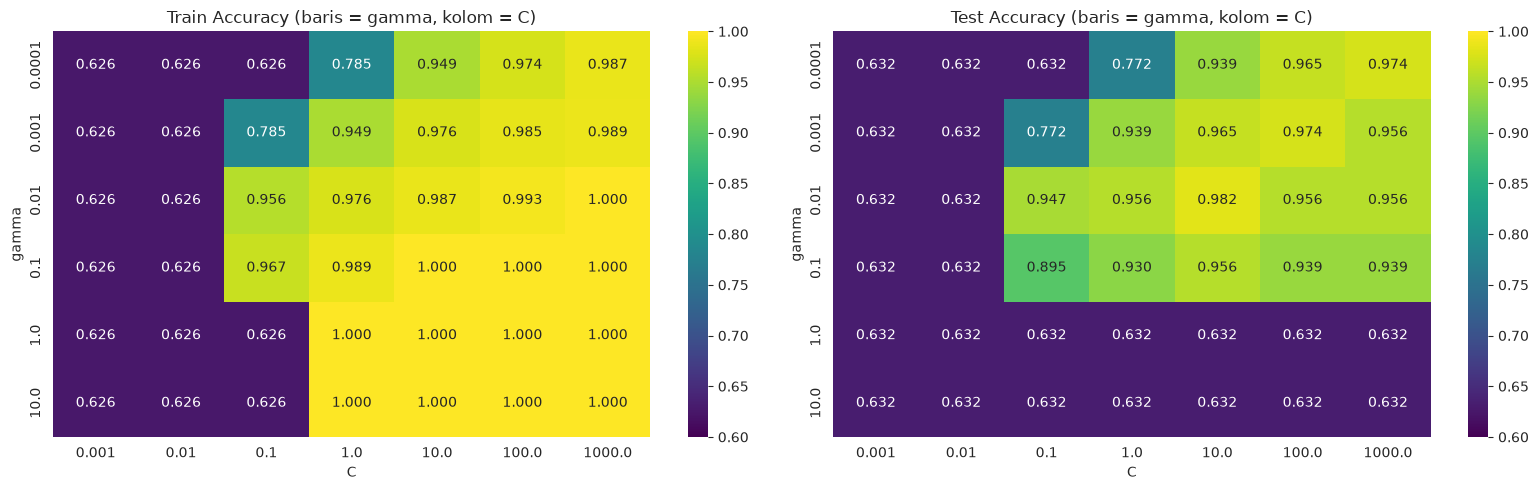

In [25]:
grid = pd.DataFrame(index=gamma_values, columns=C_values, dtype=float)
grid_train = grid.copy()
for g in gamma_values:
    for c in C_values:
        model = SVC(kernel='rbf', C=c, gamma=g).fit(X_train_scaled, y_train)
        grid.loc[g, c] = accuracy_score(y_test, model.predict(X_test_scaled))
        grid_train.loc[g, c] = accuracy_score(y_train, model.predict(X_train_scaled))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, data) in zip(axes, {'Train': grid_train, 'Test': grid}.items()):
    sns.heatmap(data, annot=True, fmt='.3f', cmap='viridis', ax=ax, vmin=0.6, vmax=1)
    ax.set_title(f'{name} Accuracy (baris = gamma, kolom = C)')
    ax.set_xlabel('C')
    ax.set_ylabel('gamma')
plt.tight_layout()
plt.show()

Heatmap kombinasi `C` × `gamma` menunjukkan bahwa kedua parameter saling berinteraksi: **gamma kecil membutuhkan C yang besar** untuk mencapai performa yang baik (misalnya gamma = 0,0001 baru mencapai 97,37% saat C = 1000), sedangkan gamma besar sudah overfitting bahkan pada C kecil. Area dengan test accuracy terbaik (≥ 97%) membentuk pita diagonal dari kiri bawah ke kanan atas, dengan nilai tertinggi 98,25% pada `gamma = 0,01, C = 10`. Baris `gamma ≥ 1` seluruhnya gagal di test set (63,16%) meski train accuracy 100% untuk C ≥ 1, contoh overfitting yang paling jelas. *(Catatan: kombinasi terbaik ini dipilih berdasarkan test set sehingga sedikit optimistis; untuk pemilihan hyperparameter yang benar sebaiknya menggunakan cross-validation pada train set.)*

# 4. Evaluasi Model

In [26]:
models = {
    'SVM Linear': linear_predictions,
    'SVM RBF': rbf_predictions,
}

scores = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, p) for p in models.values()],
    'Precision': [precision_score(y_test, p) for p in models.values()],
    'Recall': [recall_score(y_test, p) for p in models.values()],
    'F1 Score': [f1_score(y_test, p) for p in models.values()],
}, index=list(models.keys()))

scores

,Accuracy,Precision,Recall,F1 Score
SVM Linear,0.964912,1.0,0.904762,0.950000
SVM RBF,0.973684,1.0,0.928571,0.962963


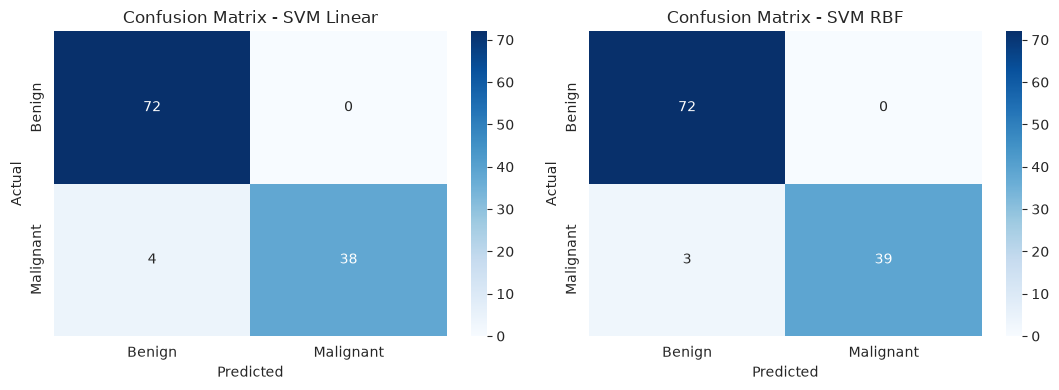

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [28]:
for name, pred in models.items():
    print(f'=== {name} ===')
    print(classification_report(y_test, pred, target_names=['Benign', 'Malignant'], digits=4))

=== SVM Linear ===
              precision    recall  f1-score   support

      Benign     0.9474    1.0000    0.9730        72
   Malignant     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114

=== SVM RBF ===
              precision    recall  f1-score   support

      Benign     0.9600    1.0000    0.9796        72
   Malignant     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



In [29]:
sv_table = pd.DataFrame({
    'SV Benign': [m.n_support_[0] for m in (svm_linear, svm_rbf)],
    'SV Malignant': [m.n_support_[1] for m in (svm_linear, svm_rbf)],
    'Total SV': [m.n_support_.sum() for m in (svm_linear, svm_rbf)],
}, index=['SVM Linear', 'SVM RBF'])
sv_table['% dari Train'] = sv_table['Total SV'] / len(X_train) * 100

sv_table

,SV Benign,SV Malignant,Total SV,% dari Train
SVM Linear,19,19,38,8.351648
SVM RBF,50,57,107,23.516484


Kedua model sama-sama memiliki **precision malignant = 1,0** (tidak ada tumor jinak yang diprediksi ganas) dan recall benign = 1,0. Perbedaannya hanya terletak pada jumlah false negative: model Linear gagal mendeteksi 4 dari 42 tumor ganas (recall 0,9048), sedangkan model RBF gagal mendeteksi 3 (recall 0,9286). Selisih hanya **1 sampel** dari 114 data test, sehingga perbedaan accuracy (96,49% vs 97,37%) dan F1 (0,950 vs 0,963) tidak dapat dianggap signifikan.

Dari sisi support vector, model Linear hanya menggunakan 38 SV (8,35% dari data train), sedangkan model RBF menggunakan 107 SV (23,52%). Model Linear lebih sederhana (batas keputusan cukup didefinisikan oleh satu vektor bobot `w`), sedangkan RBF membutuhkan lebih banyak titik untuk membentuk batas keputusan yang melengkung.

Explained variance 2 komponen: 0.6314


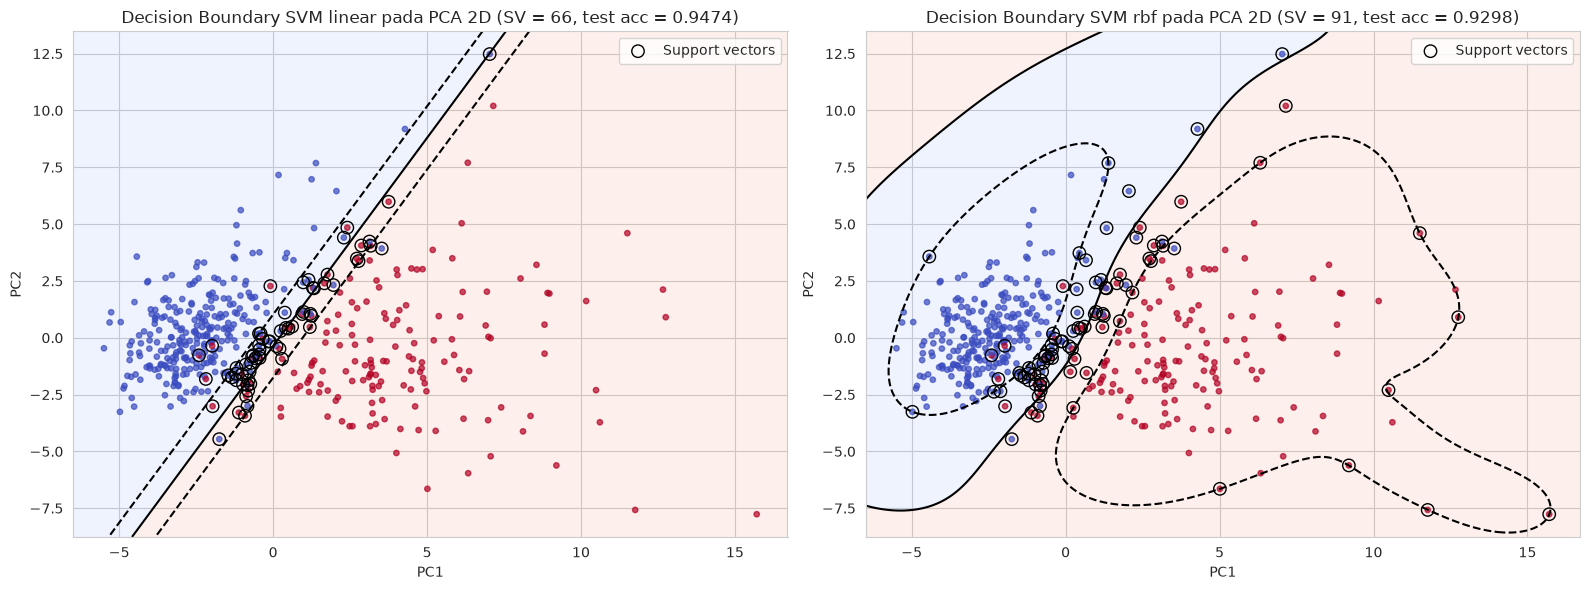

In [30]:
pca = PCA(n_components=2).fit(X_train_scaled)
X_train_2d = pca.transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)
print('Explained variance 2 komponen:', pca.explained_variance_ratio_.sum().round(4))

xx, yy = np.meshgrid(np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 400),
                     np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 400))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, kernel in zip(axes, ['linear', 'rbf']):
    model_2d = SVC(kernel=kernel, C=1.0, gamma='scale').fit(X_train_2d, y_train)
    Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z > 0, alpha=0.15, cmap='coolwarm')
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', s=15, alpha=0.7)
    ax.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1],
               s=80, facecolors='none', edgecolors='k', linewidths=1, label='Support vectors')
    test_acc = accuracy_score(y_test, model_2d.predict(X_test_2d))
    ax.set_title(f'Decision Boundary SVM {kernel} pada PCA 2D (SV = {model_2d.n_support_.sum()}, test acc = {test_acc:.4f})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

plt.tight_layout()
plt.show()

Visualisasi dilakukan pada data yang direduksi ke 2 komponen PCA (menjelaskan 63,14% variansi), dengan model yang dilatih ulang pada data 2D tersebut, sehingga performanya berbeda dari model 30 fitur. Garis tegas menunjukkan decision boundary (f(x) = 0), garis putus-putus menunjukkan margin (f(x) = ±1), dan titik yang dilingkari merupakan support vector.

Pada model Linear, batas keputusan berupa garis lurus diagonal yang melewati celah antara kedua cluster, dan sudah memisahkan kedua cluster dengan cukup baik (test accuracy 94,74%, 66 SV). Model RBF membentuk batas yang melengkung, dan margin-nya bahkan "membungkus" titik-titik malignant yang terletak jauh di kanan bawah (outlier) sehingga titik-titik tersebut ikut menjadi support vector. Model ini justru memiliki test accuracy lebih rendah (92,98%) dengan support vector lebih banyak (91 SV). Hal ini menguatkan temuan bahwa pada dataset ini fleksibilitas tambahan dari kernel RBF tidak memberikan banyak manfaat, karena struktur datanya memang hampir linear. Support vector pada kedua model terkonsentrasi di area perbatasan antar kelas, sesuai teori bahwa hanya titik di sekitar margin yang menentukan hyperplane.

# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.

# 5. Analisis

**1. Perbandingan Kernel Linear vs RBF**

| Model | Accuracy | Precision | Recall | F1 Score | Jumlah SV |
|---|---|---|---|---|---|
| SVM Linear (C=1) | 0.9649 | 1.0000 | 0.9048 | 0.9500 | 38 |
| SVM RBF (C=1, gamma=scale) | 0.9737 | 1.0000 | 0.9286 | 0.9630 | 107 |

Kernel RBF sedikit unggul dari kernel Linear, namun perbedaannya **tidak signifikan**: hanya 1 tumor ganas tambahan yang berhasil dideteksi dari 114 data test. Hal ini sesuai dengan hasil EDA, di mana pairplot dan proyeksi PCA menunjukkan kedua kelas sudah terpisah dengan batas yang hampir lurus, serta banyak fitur yang berkorelasi linear kuat dengan target (r > 0,7). Karena data sudah hampir *linearly separable* di ruang fitur aslinya (30 dimensi), proyeksi ke dimensi yang lebih tinggi oleh kernel RBF hanya memberi sedikit keuntungan di area perbatasan. Bahkan pada visualisasi PCA 2D, kernel Linear justru lebih baik (94,74% vs 92,98%). Dengan performa yang hampir setara, model Linear memiliki keunggulan dari sisi kesederhanaan, kecepatan, dan interpretabilitas (koefisien `w` dapat dibaca sebagai bobot fitur).

**2. Eksperimen Regularisasi (C dan gamma)**

Pada variasi `C` (gamma = scale), model mengalami **underfitting** pada C ≤ 0,01 (memprediksi semua sampel benign, akurasi = baseline 63%), mencapai **performa optimal** pada C = 1–10 (test 97,37%), dan mulai menunjukkan gejala **overfitting** pada **C = 100**, yang terlihat dari train accuracy mencapai 100% sementara test accuracy turun menjadi 96,49%. Ciri overfitting pada grafik adalah kurva train dan test yang mulai **saling menjauh**: kurva train terus naik hingga mentok di 1,0, sedangkan kurva test berhenti naik lalu menurun. Efek overfitting dari C relatif ringan pada dataset ini, karena C besar hanya mempersempit margin tanpa membuat batas keputusan menjadi terlalu lokal.

Sebaliknya, `gamma` menunjukkan efek overfitting yang jauh lebih ekstrem: pada gamma ≥ 1, train accuracy 100% namun test accuracy jatuh ke 63,16% (sama dengan baseline), dan seluruh 455 data train menjadi support vector, yang berarti model benar-benar menghafal setiap titik. Heatmap `C` × `gamma` juga menunjukkan bahwa keduanya harus diatur bersamaan: kombinasi terbaik pada eksperimen ini adalah `gamma = 0,01, C = 10` (test 98,25%).

**3. Jumlah Support Vector dan Kompleksitas Batas Keputusan**

Model Linear hanya membutuhkan 38 support vector (8,35% data train), sedangkan RBF membutuhkan 107 (23,52%). Batas keputusan Linear berupa hyperplane datar yang cukup ditentukan oleh sedikit titik di perbatasan, sedangkan RBF membentuk batas yang melengkung sehingga membutuhkan lebih banyak titik sebagai "penopang". Namun, hubungan jumlah SV dengan kompleksitas tidak selalu searah: pada eksperimen C, jumlah SV **berkurang** saat C naik (340 → 70) karena margin semakin sempit, sedangkan pada eksperimen gamma, jumlah SV **bertambah** drastis saat gamma terlalu besar (hingga 455). Jumlah SV yang mendekati jumlah seluruh data train, baik karena underfitting (C sangat kecil, margin terlalu lebar) maupun overfitting (gamma sangat besar), merupakan tanda bahwa model tidak menggeneralisasi dengan baik.

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

# 6. Kesimpulan dan Saran

**Kesimpulan:**
Pada tugas klasifikasi tumor payudara menggunakan Breast Cancer Wisconsin (Diagnostic) Dataset, SVM mampu mencapai performa yang sangat baik. **Kernel RBF (C=1, gamma=scale) sedikit unggul** dibanding kernel Linear (accuracy 97,37% vs 96,49%, F1 0,963 vs 0,950), namun selisihnya hanya 1 sampel test, sehingga pada dataset yang hampir *linearly separable* ini kernel Linear sudah memadai dan lebih sederhana (38 vs 107 support vector). Kedua model tidak menghasilkan false positive sama sekali (precision = 1,0), dan kesalahan yang terjadi hanya berupa 3–4 tumor ganas yang tidak terdeteksi.

**Feature scaling terbukti sangat krusial** untuk SVM: tanpa scaling, test accuracy RBF turun dari 97,37% menjadi 90,35%, karena fitur berskala besar seperti `area_worst` mendominasi perhitungan jarak. Dari sisi regularisasi, `C` yang terlalu kecil (≤ 0,01) menyebabkan underfitting, sedangkan C ≥ 100 mulai menunjukkan overfitting (train 100%, test turun). Parameter `gamma` memberikan efek yang lebih sensitif: gamma ≥ 1 menyebabkan overfitting ekstrem (train 100%, test hanya 63%).

**Saran:**
1. **Hyperparameter tuning dengan `GridSearchCV`** (Stratified K-Fold) pada kombinasi `C` dan `gamma`, karena pemilihan berdasarkan test set seperti pada eksperimen ini cenderung optimistis, terlebih dengan test set yang hanya berisi 114 sampel.
2. **Mengutamakan recall kelas malignant**, misalnya dengan `class_weight='balanced'` atau menggeser threshold `decision_function`, karena dalam konteks medis false negative (kanker tidak terdeteksi) jauh lebih berbahaya daripada false positive.
3. **Mencoba kernel Polynomial** sebagai pembanding, serta **seleksi fitur** untuk mengurangi redundansi (misalnya hanya memakai salah satu dari radius/perimeter/area) agar model lebih ringkas.
4. **Membandingkan dengan model lain** seperti Logistic Regression (juga linear dan lebih mudah diinterpretasi) atau Random Forest, untuk memastikan apakah SVM memang pilihan terbaik untuk dataset ini.